Simple data-exploration to get a feel for the histogram of the players

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Master dictionary created.

Sorting players and identifying top performers by position...
Top 5 Forwards: ['Erling Haaland', 'Ollie Watkins', 'Nicolas Jackson', 'Alexander Isak', 'Kai Havertz']
Top 5 Midfielders: ['Mohamed Salah', 'Bukayo Saka', 'Martin Ødegaard', 'Phil Foden', 'Son Heung-min']
Top 5 Defenders: ['Benjamin White', 'Kieran Trippier', 'Gabriel dos Santos Magalhães', 'William Saliba', 'Trent Alexander-Arnold']
Median 5 Players: ['Cheick Doucouré', 'Benoît Badiashile', 'Nayef Aguerd', 'Arijanet Muric', 'Ben Chilwell']
Displaying plots. Close the plot window to end the script.


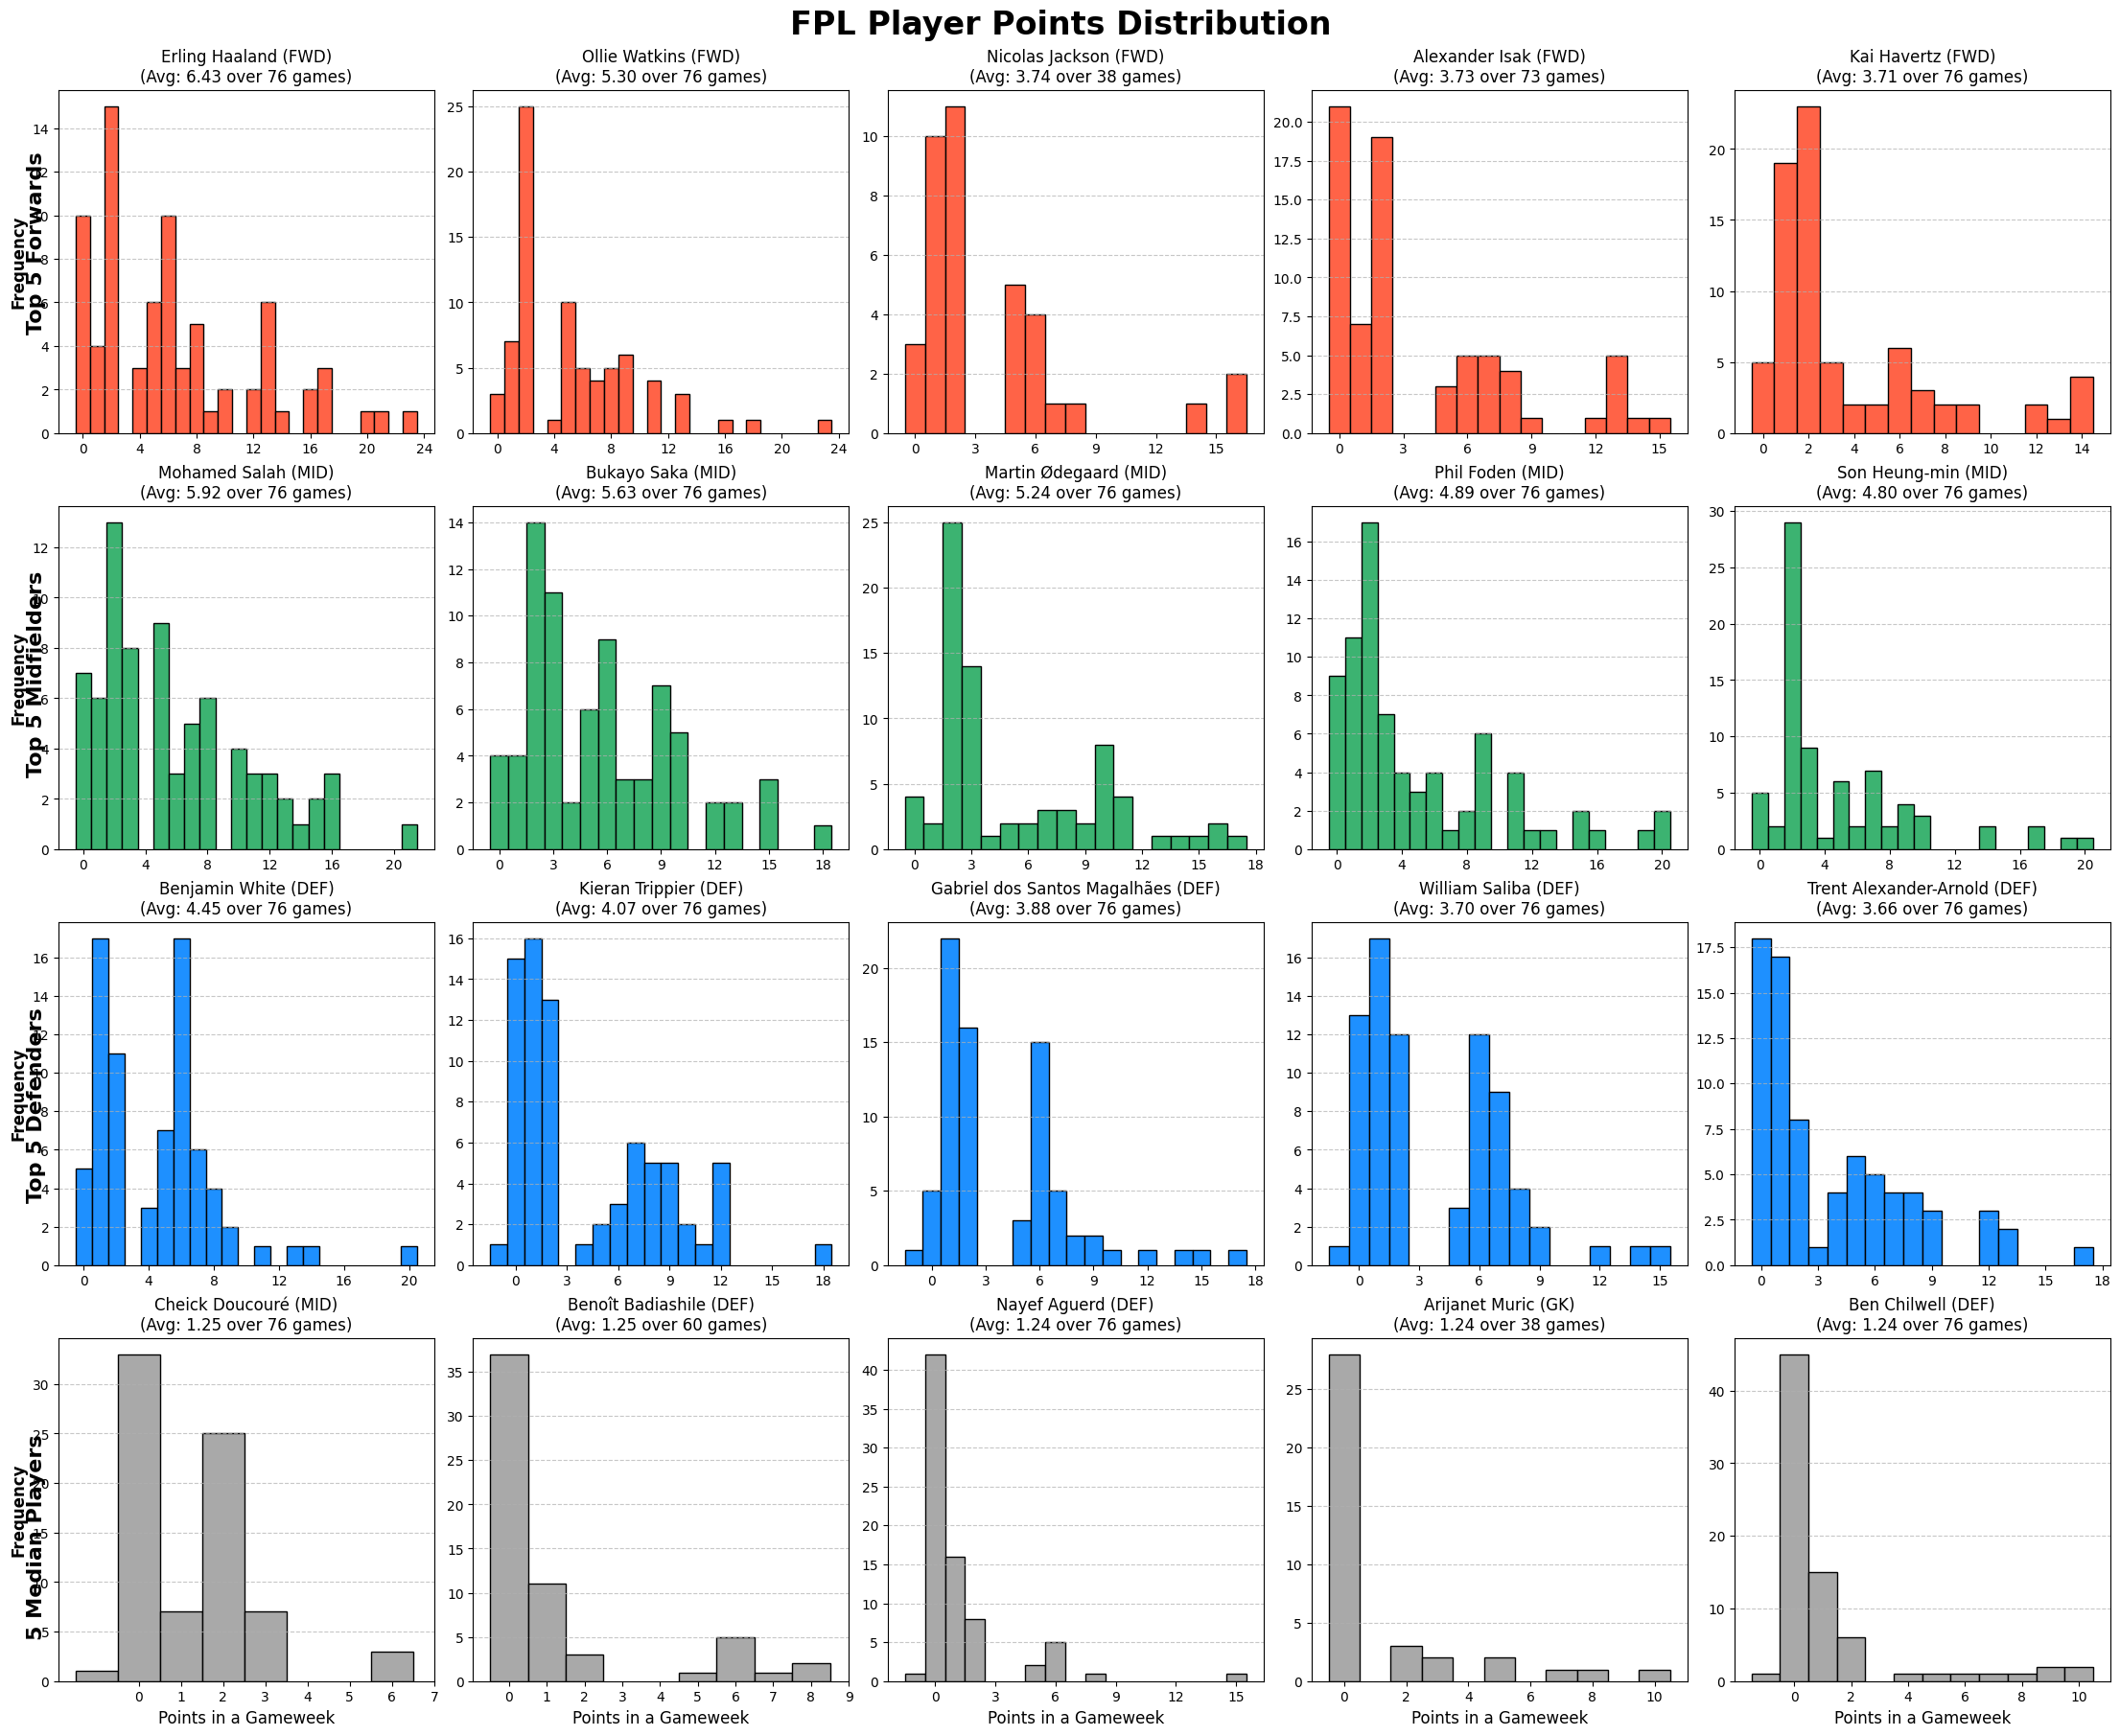

In [ ]:
# We now need the 'position' column to filter players
histogram_features = ['name', 'total_points', 'position']

try:
    # Loading data from previous seasons
    df_22_23 = pd.read_csv("../data/historic_data/2022-23/gws/merged_gw.csv", usecols=histogram_features)
    df_23_24 = pd.read_csv("../data/historic_data/2023-24/gws/merged_gw.csv", usecols=histogram_features)

    # Getting players for the upcoming season
    df_25_26_names = pd.read_csv("../data/player_idlist.csv")
    df_25_26_names['name'] = df_25_26_names['first_name'] + " " + df_25_26_names['second_name']
    current_players = set(df_25_26_names['name'])

except FileNotFoundError as e:
    print(f"Error loading data: {e}")
    print("Please ensure your file paths are correct. Exiting.")
    exit()

# Combine all historical data into a single DataFrame
# For now, using only the two seasons provided in your non-working code
df_all_seasons = pd.concat([df_22_23, df_23_24], ignore_index=True)

# Filter for players active in the upcoming season
df_filtered = df_all_seasons[df_all_seasons['name'].isin(current_players)].copy()

# Create the Points Occurrence Dictionary 
point_counts = df_filtered.groupby(['name', 'total_points']).size()

player_histogram_dict = {}
for (name, points), count in point_counts.items():
    player_histogram_dict.setdefault(name, {})[points] = count

print("Master dictionary created.")

# Sort Players and Identify Top by Position 
print("\nSorting players and identifying top performers by position...")

# Calculate base statistics (mean, count) for each player
player_stats = df_filtered.groupby('name')['total_points'].agg(['mean', 'count']).rename(columns={'mean': 'average_score'})

# Determine each player's primary position (most frequent one)
# This handles cases where a player might have changed positions
player_primary_position = df_filtered.groupby('name')['position'].agg(lambda x: x.mode()[0])

# Combine stats with position information
player_stats = player_stats.join(player_primary_position)

# Sort the combined stats DataFrame by average score
sorted_stats = player_stats.sort_values('average_score', ascending=False)

# Identify the top 5 players for each position from the sorted list
top_5_fwd = sorted_stats[sorted_stats['position'] == 'FWD'].head(5).index.tolist()
top_5_mid = sorted_stats[sorted_stats['position'] == 'MID'].head(5).index.tolist()
top_5_def = sorted_stats[sorted_stats['position'] == 'DEF'].head(5).index.tolist()

# Identify the 5 median players from the overall sorted list
sorted_player_names = sorted_stats.index.tolist()
n_players = len(sorted_player_names)
median_index = n_players // 2
median_5_players = sorted_player_names[median_index - 2 : median_index + 3]

print("Top 5 Forwards:", top_5_fwd)
print("Top 5 Midfielders:", top_5_mid)
print("Top 5 Defenders:", top_5_def)
print("Median 5 Players:", median_5_players)


def plot_player_histogram(ax, player_name, player_data, stats_df, color='skyblue'):
    """Plots a histogram for a single player on a given axes object."""
    points_data = player_data.get(player_name)
    if not points_data or player_name not in stats_df.index:
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center')
        ax.set_title(f"{player_name}\n(No Data)")
        ax.set_xticks([])
        ax.set_yticks([])
        return
        
    points = sorted(points_data.keys())
    counts = [points_data[p] for p in points]
    
    avg_score = stats_df.loc[player_name, 'average_score']
    games_played = stats_df.loc[player_name, 'count']
    position = stats_df.loc[player_name, 'position']
    
    ax.bar(points, counts, color=color, edgecolor='black', width=1.0)
    ax.set_title(f"{player_name} ({position})\n(Avg: {avg_score:.2f} over {int(games_played)} games)")
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    max_point = max(points) if points else 0
    ax.set_xticks(np.arange(0, max_point + 2, step=max(1, (max_point // 5))))

# Create a 4x5 grid for the plots
fig, axes = plt.subplots(nrows=4, ncols=5, figsize=(22, 18), constrained_layout=True)
fig.suptitle('FPL Player Points Distribution', fontsize=24, weight='bold')

# Plotting each category on its own row 
categories = {
    'Top 5 Forwards': (top_5_fwd, 'tomato'),
    'Top 5 Midfielders': (top_5_mid, 'mediumseagreen'),
    'Top 5 Defenders': (top_5_def, 'dodgerblue'),
    '5 Median Players': (median_5_players, 'darkgray')
}

for row_index, (title, (player_list, color)) in enumerate(categories.items()):
    # Add a row title
    axes[row_index, 0].set_ylabel("Frequency", fontsize=12, weight='bold')
    fig.text(0.01, (3.45 - row_index) / 4.0, title, va='center', rotation='vertical', fontsize=16, weight='bold')

    for col_index, player_name in enumerate(player_list):
        plot_player_histogram(axes[row_index, col_index], player_name, player_histogram_dict, sorted_stats, color=color)

# Set common X-label for the last row
for ax in axes[3]:
    ax.set_xlabel("Points in a Gameweek", fontsize=12)

print("Displaying plots. Close the plot window to end the script.")
plt.show()